## Carga inicial de librerías y data

In [9]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
data = pd.read_csv('breast_cancer.csv')

Primero cargamos el dataset CuMiDa GSE45827. Realizamos una limpieza básica eliminando la columna samples porque es un identificador numérico que no aporta información biológica. Separamos las variables independientes (las mediciones de los 54,676 genes) en la matriz X, y la variable dependiente (el subtipo de cáncer de mama o tejido sano) en el vector y.

## Limpieza de data y aplicación de PCA

In [ ]:
X = data.drop(columns=['samples', 'type'])
y = data['type']

print("Datos cargados: {X.shape[0]} muestras y {X.shape[1]} genes.")

Datos cargados: {X.shape[0]} muestras y {X.shape[1]} genes.


Ahora con el fin de empezar a hacer que el modelo aprenda se divide el dataset en un 80% para entrenar un 20% para testear. Como hay muchos subtipos de cáncer se debe asegurar que todos estén en igualdad de condiciones por lo que los parámetros dentro de la división no sesgan las clases.

In [8]:
#Se separa ahora un grupo de datos para entrenar y otro para evaluar el modelo.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Según la clase de reudcción de la dimensionalidad, el pca es muy sensible a magnitudes por lo que se deben normalizar los datos para que todos los genes tengan una media y covarianza igual, es decir, 0 y 1 respectivamente. El pca busca las direcciones de varianza más altas y por tanto si se evita hacer esto los genes con valores numéricamente más grandes tendrían más presencia en el algoritmo de forma inequitativa

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Una vez que se tiene normalizado el dataset se busca evitar la maldición de la dimensionalidad ya que al tener 54676 genes representados en la misma cantidad de columnas y 151 filas de muestra se debe usar una dimensión "posible"

In [11]:
pca_completo = PCA()
pca_completo.fit(X_train_scaled)

varianza_acumulada = np.cumsum(pca_completo.explained_variance_ratio_)

n_componentes_85 = np.argmax(varianza_acumulada >= 0.85) + 1
print(f"Para explicar el 85% de la varianza se necesitan: {n_componentes_85} componentes.")

Para explicar el 85% de la varianza se necesitan: 73 componentes.


Se identifica entonces que con 73 componentes ya se cubre el 85% de la información total. Esto permite simplificar el modelo y limpiar el ruido repetitivo sin perder calidad en los datos importantes.

In [12]:
pca = PCA(n_components=73)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

Con los 76 componentes que se eligieron antes, se arma el modelo PCA definitivo. Se pasan los datos originales, que eran enormes y complejos, a unas matrices nuevas mucho más compactas las cuales son X_train_pca y X_test_pca. Ahora, cada columna es un componente principal independiente, es decir, representa un componente principal ortogonal, lo que significa que no hay información repetida ni correlación entre ellas.

## Visualización Gráfica de componentes

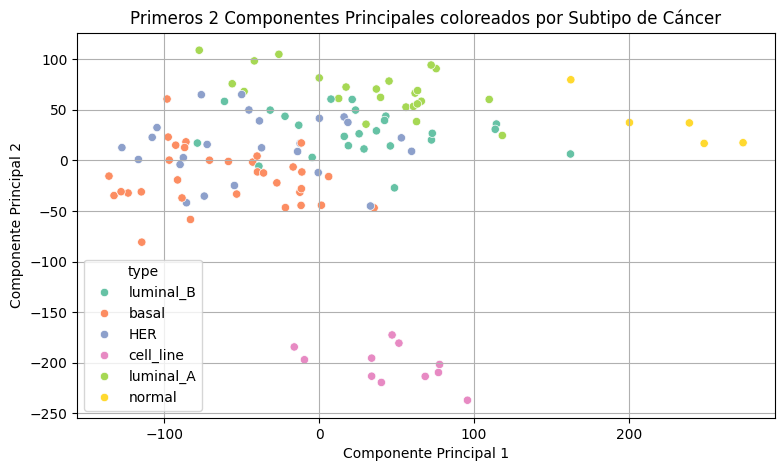

In [16]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train, palette='Set2')

plt.title('Primeros 2 Componentes Principales coloreados por Subtipo de Cáncer')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

Al proyectar los datos en los dos primeros componentes principales:
- El grupo normal en color amarillo (tejido sano) se agrupa hacia el extremo derecho del eje del Componente Principal 1. Esto demuestra que el PC1  logra separar claramente las células sanas de las células con cáncer usando su información genética.

- El grupo cell_line en morado (líneas celulares de laboratorio) aparece desplazado en el extremo inferior del eje del Componente Principal 2. Esta separación es biológicamente esperable y consistente con el estudio ya que las células cultivadas en laboratorio cambian debido a la falta de entorno fisiológico (vasos sanguíneos, defensas), lo que altera la expresión genética. Debido a esta adaptación al plástico, el análisis matemático identifica estas muestras como distintas a los tumores reales, esto según la base de datos pública de expresión genética alojada en el National Center for Biotechnology Information (NCBI).

- Los subtipos tumorales activos (luminal_A, luminal_B, basal y HER) se encuentran mezclados en la región central del gráfico y se superponen a visualizaciones planas 2D debido a sus características continuas según PathologyOutlines.
Por lo tanto, se debe usar un modelo de Regresión Logística que operará sobre los 76 componentes principales seleccionados (que representan el 85% de la varianza explicada)

Siguiendo con la clase de reducción de la dimensionalidad, los loadings representan el peso o contribución que cada variable original aporta a la construcción de los nuevos componentes principales. 

In [19]:
#Loadings del primer componente
loadings_pc1 = pca.components_[0] # Coeficientes matemáticos de la combinación lineal

genes_pesos = pd.Series(loadings_pc1, index=X.columns)

top_10_genes = genes_pesos.abs().sort_values(ascending=False).head(10)

print("Top 10 genes con mayor impacto en el PC1:")
print(genes_pesos[top_10_genes.index])

Top 10 genes con mayor impacto en el PC1:
220904_at       0.010709
1552889_a_at    0.010580
216102_at       0.010548
206849_at       0.010448
208260_at       0.010372
225952_at       0.010273
206119_at       0.010262
239592_at       0.010257
1569393_at      0.010245
242921_at       0.010227
dtype: float64


Al analizar los loadings del PC1, se extrajeron los 10 genes con mayor impacto absoluto, liderados por 220904_at con ($0.010709$), seguido en orden por 1552889_a_at, 216102_at, 206849_at, 208260_at, 225952_at, 206119_at, 239592_at, 1569393_at y 242921_at. El estudio del loaging se hace directamente en el PC1 debido a que como se observa en el eje horizontal del gráfico de dispersión de los dos primeros componentes, el PC1 es el responsable directo de separar por completo el tejido sano (amarillo) del tejido enfermo. Como el dataset contiene 54,676 genes estos 10 genes actúan como los principales y de mayor influencia.

## LR con GRID Search

In [ ]:
#Definir modelo base
lr = LogisticRegression(max_iter=5000, solver='saga', random_state=42)

# Definir los parámetros a probar (C es la fuerza, penalty el tipo)
parametros = {
    'C': [0.1, 1.0, 10.0],
    'penalty': ['l1', 'l2']
}

# Validación Cruzada de 3 carpetas (cv=3)
grid = GridSearchCV(estimator=lr, param_grid=parametros, cv=3, scoring='accuracy')
grid.fit(X_train_pca, y_train)

print(f"Mejores hiperparámetros: {grid.best_params_}")

Mejores hiperparámetros: {'C': 1.0, 'penalty': 'l1'}


El algoritmo determinó que la configuración óptima para clasificar los subtipos de cáncer de mama consiste en utilizar una penalización Lasso (penalty: 'l1') junto con un valor de C: 1.0. Como se revisó en clases anteriores, el método de regularización Lasso actúa como un filtro que previene el overfitting al ponerle un peso a las variables; si un componente no aporta información realmente útil para la clasificación, Lasso reduce su peso paulatinamente hasta bajarlo exactamente a cero. Por su parte, el hiperparámetro C controla esta regularización. El resultado obtenido de C: 1.0 representa la presión justa de Lasso para limpiar las variables irrelevantes dentro de los 76 componentes principales seleccionados.

## Matriz de confusión y métricas

In [28]:
#elegir el modelo del grid pq como ya probó varias combinaciones, es el que mejor se desempeñó
mejor_modelo = grid.best_estimator_
predicciones = mejor_modelo.predict(X_test_pca)

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(y_test, predicciones))

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, predicciones))

--- MATRIZ DE CONFUSIÓN ---
[[6 0 0 0 0 0]
 [1 7 0 0 0 0]
 [0 0 3 0 0 0]
 [0 0 0 5 1 0]
 [0 0 0 0 6 0]
 [0 0 0 1 0 1]]

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

         HER       0.86      1.00      0.92         6
       basal       1.00      0.88      0.93         8
   cell_line       1.00      1.00      1.00         3
   luminal_A       0.83      0.83      0.83         6
   luminal_B       0.86      1.00      0.92         6
      normal       1.00      0.50      0.67         2

    accuracy                           0.90        31
   macro avg       0.92      0.87      0.88        31
weighted avg       0.91      0.90      0.90        31



La evaluación del modelo de Regresión Logística evidencia un desempeño bueno en la clasificación de los subtipos analizados. La matriz de confusión muestra una marcada concentración de predicciones correctas en la diagonal principal, con 28 de 31 muestras clasificadas correctamente, lo que se traduce en una exactitud del 90 %. Los subtipos HER, cell_line y luminal_B alcanzaron un recall de 1.00, indicando que todas sus muestras fueron identificadas correctamente, mientras que la clase cell_line destacó al obtener valores perfectos de precisión, recall y F1-score. Si es que existen confusiones aisladas estas explican el menor rendimiento observado en la clase normal, que presentó un recall de 0.50 y un F1-score de 0.67. No obstante, los promedios ponderados de precisión (0.91), recall (0.90) y F1-score (0.90) reflejan un comportamiento consistente y equilibrado entre las distintas categorías. 

## Referencias

- Gruosso T, Kieffer Y, Dubois T, Mechta-Grigoriou F. Expression data from Breast cancer subtypes [Internet]. National Center for Biotechnology Information (US); 2013 [actualizado 2019; citado jun 2026]. Disponible en: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE45827 

- Molecular subtypes [Internet]. Pathology Outlines; 2024 [actualizado 23 ene 2024; citado jun 2026]. Disponible en: https://www.pathologyoutlines.com/topic/breastmolecularsubtypes.html 